# Objectif du notebook 

Date de création : 17/09/2025

L'objectif du notebook est de reprendre l'analyse des données Fiberscope afin de s'assurer de la comformité des résultats obtenus avec la méthode RTF-MFP et d'éliminer toutes les zones d'ombre possibles. 

Pour ce faire, l'analyse s'articule en plusieurs étapes : 

# Etape 1 : choix de la taille des fenêtres STFT utilisée (paramètre $n_{stft}$)

Cette première étape est essentielle afin d'assurer les performances de la méthode MFP-RTF. Plusieurs approches sont possibles : 

* Approche 1 : minimisation de la distance au vecteur de RTF estimé par déconvolution. 
* Approche 2 : hypothèse propagation longue distance et estimation de la durée de la durée de la réponse impulsionnelle à l'aide de la vitesse de groupe minimale sur la bande de fréquence. 

In [1]:
import os 
import sys 
import numpy as np 
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt  

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import params
from time import time
from scipy.linalg import eigh
from scipy.optimize import least_squares

from utils import load_fiberscope_data
from fiberscope_manager import FiberscopeManager
from fiberscope_recording import FiberscopeSweep1, FiberscopeSweep2, FiberscopeDynamicRecording
from propa.rtf.rtf_utils import D_hermitian_angle_fast, normalize_metric_contrast

from publication.publication_figure import color

In [2]:
# Useful properties
h_index_ref = 5     # On choisit le récepteur avec le plus haut SNR 

# Flags 
run_static_demo = False

# RTF estimator 
# rtf_static_estimator = "cs"
rtf_static_estimator = "cs-evd"

### Première illustration avec le paramètre par défaut 

In [3]:
# Load and preprocess static record
fs_sweep = FiberscopeSweep1()
# fs_sweep = FiberscopeSweep2()
# 
records_to_process = fs_sweep.records_N1
# records_to_process = fs_sweeparams.records_N1 + fs_sweep.records_N3 + fs_sweep.records_N5
fs_sweep.records_folder = os.path.join(params.root_data, "static")
if not os.path.exists(fs_sweep.records_folder):
    os.makedirs(fs_sweep.records_folder)

if run_static_demo:
    fsm = FiberscopeManager(
        root_processed_data=params.root_data, h_index_ref=h_index_ref, plot_feature=True
    )
    fsm.process_static_analysis(
        static_signal=fs_sweep,
        static_records_names=records_to_process,
        rtf_estimator=rtf_static_estimator,
    )

In [4]:
dist_func = D_hermitian_angle_fast
ax_f = 1
ax_rcv = 0
dist_kwargs = {
    "ax_f": ax_f,
    "unit": "deg",
    "ax_rcv": ax_rcv,
    "apply_mean": True,
    "apply_median": False,
}


In [5]:
# Compare RTF estimated by deconvolution and by CS-EVD on a restricted frequency band
fmin = 11.9 * 1e3  # Hz
fmax = 12 * 1e3  # Hz
print(f"Frequency band: [{fmin/1e3}, {fmax/1e3}] kHz")

Frequency band: [11.9, 12.0] kHz


In [6]:
# Define the order based on the source position : from closest to farthest
dict_th_pos = params.dict_th_pos
all_dists = np.array([dict_th_pos[pos] for pos in dict_th_pos.keys()])
idx_pos_sort = np.argsort(all_dists)
src_labels = list(dict_th_pos.keys())
src_label_sorted = [src_labels[i] for i in idx_pos_sort]
all_dists_sorted = all_dists[idx_pos_sort]

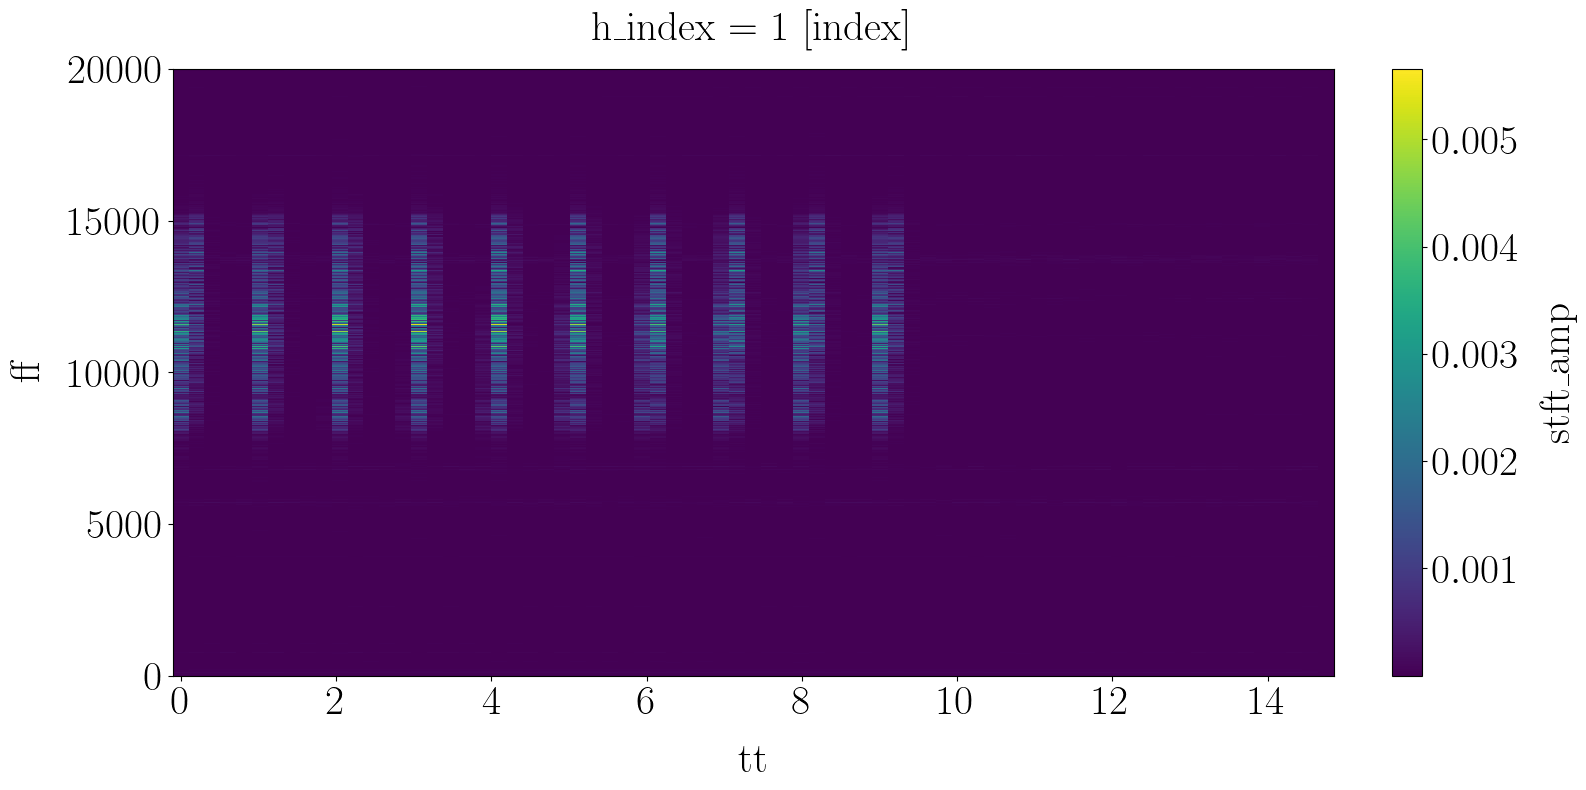

In [7]:
plot_limited_freq = False
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\rtf_estimation_visual_inspection\static"
# Plot RTF ref and RTF hat on the frequency band of interest
records_to_plot = records_to_process[1:2]
# records_to_plot = records_to_process

for record_name in records_to_plot:

    # Load data
    ds_rtf_fpath = os.path.join(params.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Plot STFT of the recorded signals
    stft_amp = ds_rtf.stft_amp.sel(h_index=1)
    stft_amp.plot(x="tt", y="ff")

In [8]:
# Compare RTF estimated by deconvolution and by CS-EVD
thetas = []
thetas_band = []


for record_name in records_to_process:

    ds_rtf_fpath = os.path.join(params.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Build RTF ref (from deconvolution)

    # from scipy.interpolate import interp1d
    # rtf_ref_mod_interp = []
    # rtf_ref_phase_interp = []
    # for hi in ds_rtf.h_index.values:

    #     interp_func = interp1d(
    #         ds_rtf.f_ir.values, ds_rtf.rtf_amp.sel(h_index=hi).values, fill_value="extrapolate"
    #     )
    #     rtf_ref_mod_interp.append(interp_func(ds_rtf.f_rtf.values))

    #     interp_func = interp1d(
    #         ds_rtf.f_ir.values,
    #         ds_rtf.rtf_phase.sel(h_index=hi).values,
    #         fill_value="extrapolate",
    #     )
    #     rtf_ref_phase_interp.append(interp_func(ds_rtf.f_rtf.values))

    # rtf_ref_mod_interp = np.array(rtf_ref_mod_interp)
    # rtf_ref_phase_interp = np.array(rtf_ref_phase_interp)

    # rtf_ref_mod = xr.Dataset(
    #     data_vars=dict(rtf_amp=(["h_index", "f_ir"], rtf_ref_mod_interp)),
    #     coords=dict(f_ir=ds_rtf.f_rtf.values, h_index=ds_rtf.h_index.values),
    # ).rtf_amp
    # rtf_ref_phase = xr.Dataset(
    #     data_vars=dict(rtf_phase=(["h_index", "f_ir"], rtf_ref_phase_interp)),
    #     coords=dict(f_ir=ds_rtf.f_rtf.values, h_index=ds_rtf.h_index.values),
    # ).rtf_phase
    # rtf_ref = rtf_ref_mod * np.exp(1j * rtf_ref_phase)

    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

    # Build RTF hat (from CS-EVD)
    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

    # Interp RTF ref at RTF hat frequencies (nearest neigbor)
    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")      # Pas de soucis avec les complexes il s'agit simplement du plus proche voisins (pas d'interpolation)

    # Compute mean theta distance over the frequency band of interest
    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

    # Distance in the reduced band of interest
    rtf_ref_band = rtf_ref.sel(f_ir=slice(fmin, fmax))
    rtf_hat_band = rtf_hat.sel(f_rtf=rtf_ref_band.f_ir.values, method="nearest")
    theta_band = dist_func(
        rtf_ref=rtf_ref_band.values, rtf=rtf_hat_band.values, **dist_kwargs
    )

    thetas.append(theta)
    thetas_band.append(theta_band)

    # print(f"Record: {record_name}")
    # print(
    #     f"theta (fullband) = {np.round(theta, 3)}°, theta ({fmin}, {fmax}) = {np.round(theta_band, 3)}°"
    # )

# Convert to np array
thetas = np.array(thetas)
thetas_band = np.array(thetas_band)

# Sort according to position order
records_to_process_sorted = [records_to_process[i] for i in idx_pos_sort]
thetas_sorted = thetas[idx_pos_sort]
thetas_band_sorted = thetas_band[idx_pos_sort]

# Display results
for ipos, rec in enumerate(records_to_process_sorted):
    print(f"Record : {rec}")
    print(f"theta (fullband) = {np.round(thetas_sorted[ipos], 3)}°")
    print(f"theta ({fmin}, {fmax}) = {np.round(thetas_band_sorted[ipos], 3)}°")

Record : 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
theta (fullband) = 2.703°
theta (11900.0, 12000.0) = 2.65°
Record : 10-10-2024T15-54-25-737795_P6_N1_Sweep_323
theta (fullband) = 2.703°
theta (11900.0, 12000.0) = 2.366°
Record : 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
theta (fullband) = 2.796°
theta (11900.0, 12000.0) = 2.252°
Record : 10-10-2024T14-42-01-833325_P5_N2_Sweep_267
theta (fullband) = 3.045°
theta (11900.0, 12000.0) = 3.037°
Record : 10-10-2024T09-43-06-620681_P3_N1_Sweep_151
theta (fullband) = 3.019°
theta (11900.0, 12000.0) = 2.82°
Record : 10-10-2024T12-03-02-201689_P4_N1_Sweep_211
theta (fullband) = 3.186°
theta (11900.0, 12000.0) = 3.244°


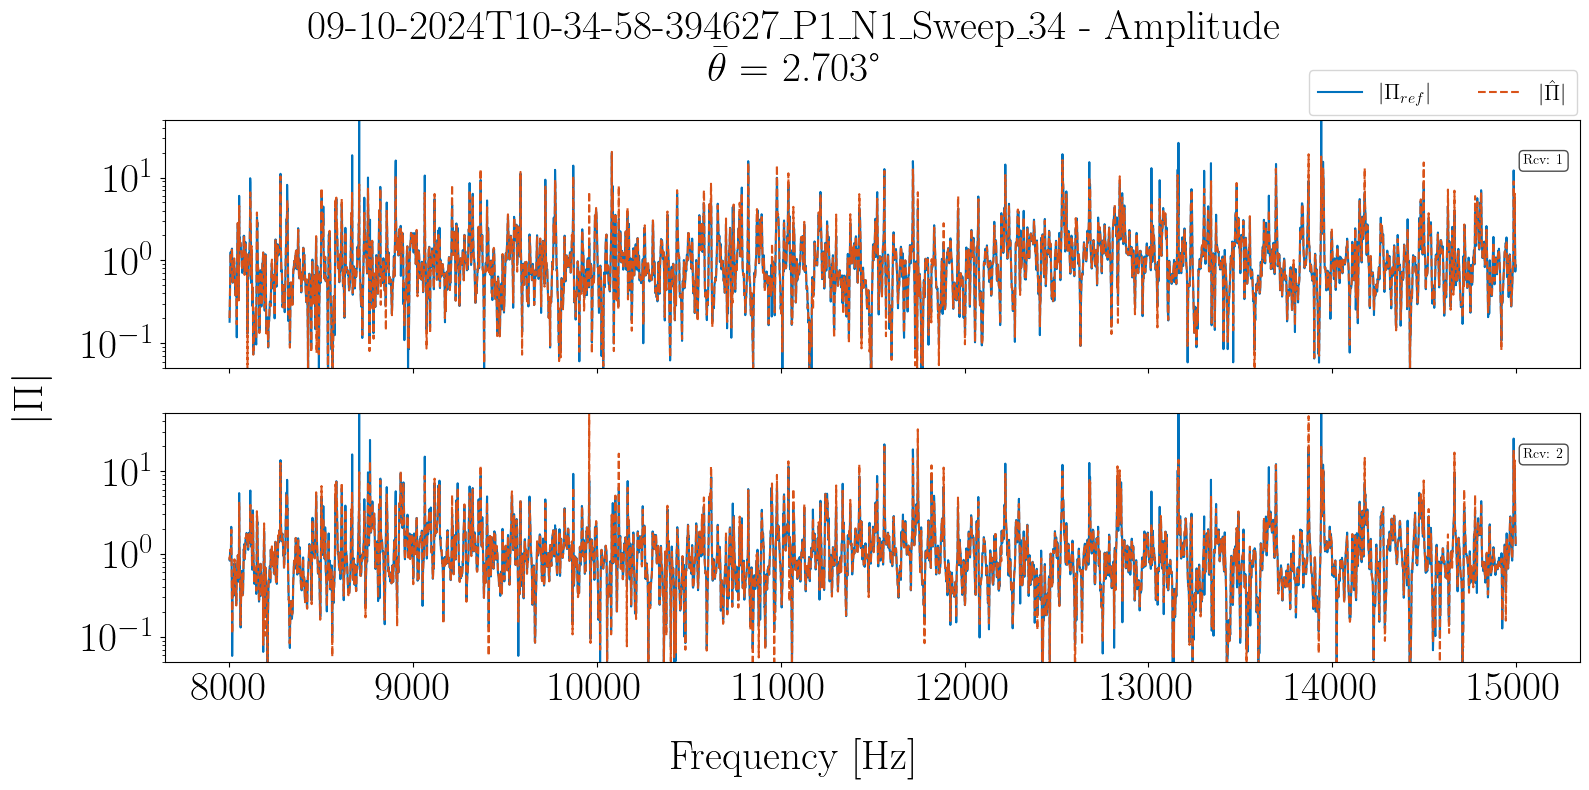

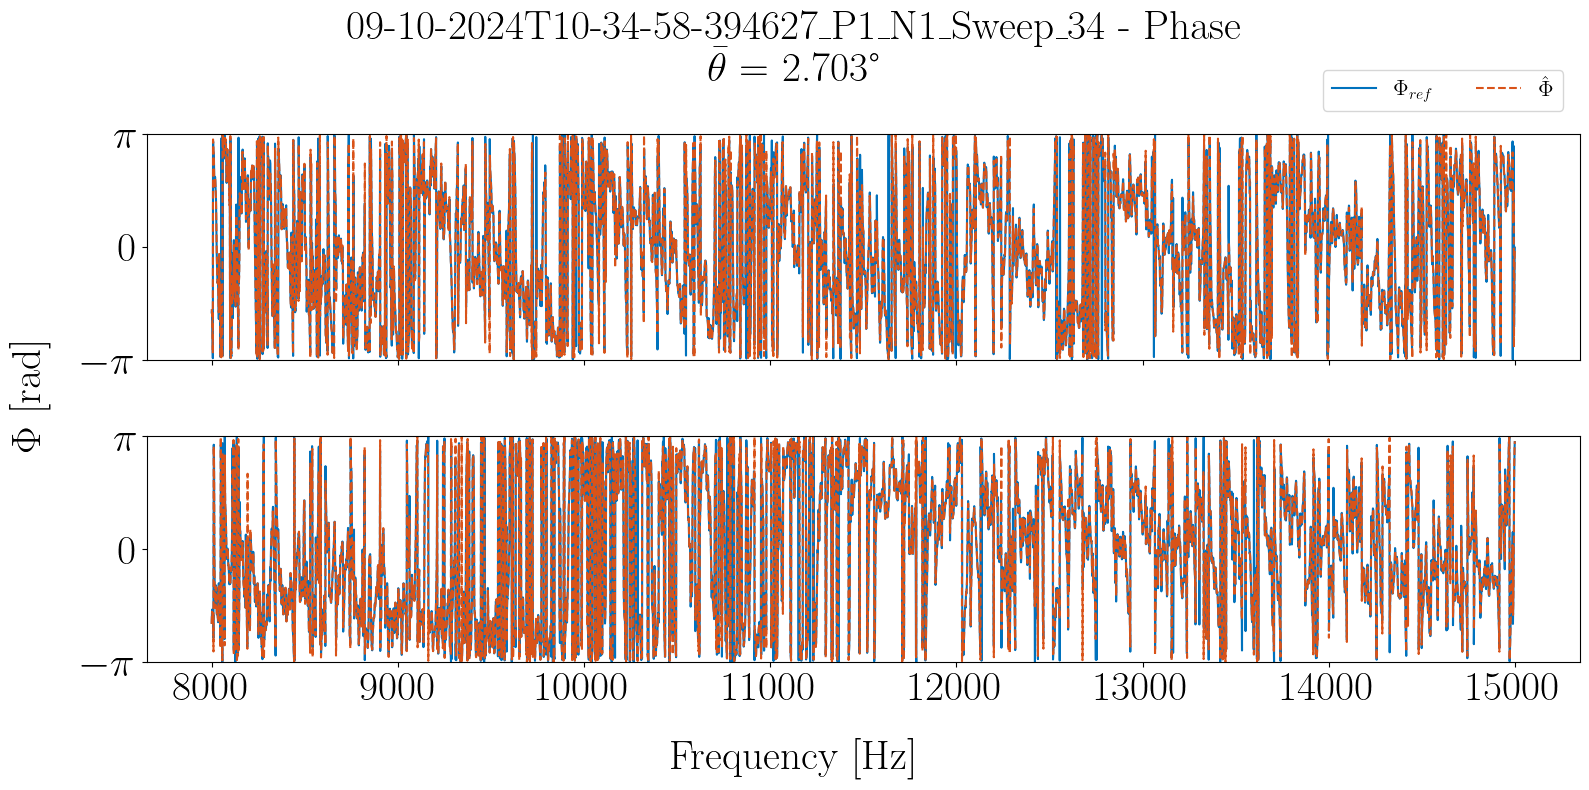

In [9]:
plot_limited_freq = False
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\rtf_estimation_visual_inspection\static"
root_img = os.path.join(root_img, rtf_static_estimator)

# Plot RTF ref and RTF hat on the frequency band of interest
records_to_plot = records_to_process
# records_to_plot = records_to_process[1:2]

first_iteration = True
for record_name in records_to_plot:

    # Load data
    ds_rtf_fpath = os.path.join(params.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Label with theta distance
    if plot_limited_freq:
        th = thetas_band[records_to_process.index(record_name)]
    else:
        th = thetas[records_to_process.index(record_name)]
    th_annotation = r"$\bar{\theta}$ = " + f"{np.round(th, 3)}°"

    nl = ds_rtf.sizes["h_index"]
    nl=2
    fig_amp, axs_amp = plt.subplots(nl, 1, sharex=True)
    fig_amp.suptitle(f"{record_name} - Amplitude" + "\n" + th_annotation)
    fig_phase, axs_phase = plt.subplots(nl, 1, sharex=True)
    fig_phase.suptitle(f"{record_name} - Phase" + "\n" + th_annotation)
    # Plot for each receiver
    for i in range(nl):
        # Select receiver
        ds_rtf_rcv = ds_rtf.isel(h_index=i)
        # Select frequency band
        if plot_limited_freq:
            ds_rtf_rcv = ds_rtf_rcv.sel(f_ir=slice(fmin, fmax))
            ds_rtf_rcv = ds_rtf_rcv.sel(f_rtf=slice(fmin, fmax))

        # Extract RTF ref (from deconvolution)
        rtf_ref_mod = ds_rtf_rcv.rtf_amp
        rtf_ref_phase = ds_rtf_rcv.rtf_phase
        # Extract RTF hat (from CS-EVD)
        rtf_hat_mod = ds_rtf_rcv.rtf_amp_hat
        rtf_hat_phase = ds_rtf_rcv.rtf_phase_hat

        # Interp RTF ref at RTF hat frequencies (nearest neigbor)
        rtf_ref_mod = rtf_ref_mod.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")
        rtf_ref_phase = rtf_ref_phase.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")
        
        # Linear interpolation
        # from scipy.interpolate import interp1d

        # interp_func = interp1d(rtf_ref_mod.f_ir.values, rtf_ref_mod.values, fill_value="extrapolate")
        # rtf_ref_mod_interp = interp_func(rtf_hat_mod.f_rtf.values)
        # rtf_ref_mod = xr.Dataset(
        #     data_vars=dict(rtf_amp=(["f_ir"], rtf_ref_mod_interp)),
        #     coords=dict(f_ir=rtf_hat_mod.f_rtf.values),
        # ).rtf_amp

        # interp_func = interp1d(
        #     rtf_ref_phase.f_ir.values, rtf_ref_phase.values, fill_value="extrapolate"
        # )
        # rtf_ref_phase_interp = interp_func(rtf_hat_phase.f_rtf.values)
        # rtf_ref_phase = xr.Dataset(
        #     data_vars=dict(rtf_phase=(["f_ir"], rtf_ref_phase_interp)),
        #     coords=dict(f_ir=rtf_hat_phase.f_rtf.values),
        # ).rtf_phase

        if plot_limited_freq:
            marker = "o"
            markersize = 2
        else:
            marker = None
            markersize = None

        # Plot RTF mod
        # plt.plot()
        rtf_ref_mod.plot(
            label=r"$|\Pi_{ref}|$",
            color=color(0),
            ax=axs_amp[i],
            marker=marker,
            markersize=markersize,
        )
        rtf_hat_mod.plot(
            label=r"$|\hat{\Pi}|$",
            color=color(1),
            linestyle="--",
            ax=axs_amp[i],
            marker=marker,
            markersize=markersize,
        )
        # if ds_rtf_rcv.h_index.values == h_index_ref:
        axs_amp[i].set_ylim(0.05, 50)
        axs_amp[i].set_xlabel("")
        axs_amp[i].set_ylabel("")
        axs_amp[i].set_yscale("log")
        axs_amp[i].set_title("")
        # axs_amp[i].set_title(f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}")
        # axs_amp[i].legend()

        # Add annotation for receiver index and record name
        axs_amp[i].annotate(
            f"Rcv: {ds_rtf_rcv.h_index.values}",
            xy=(0.96, 0.82),
            xycoords="axes fraction",
            fontsize=10,
            color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
        )

        # Plot phase
        rtf_ref_phase.plot(
            label=r"$\Phi_{ref}$",
            color=color(0),
            ax=axs_phase[i],
            marker=marker,
            markersize=markersize,
        )
        rtf_hat_phase.plot(
            label=r"$\hat{\Phi}$",
            color=color(1),
            linestyle="--",
            ax=axs_phase[i],
            marker=marker,
            markersize=markersize,
        )
        axs_phase[i].set_xlabel("")
        axs_phase[i].set_ylabel("")
        axs_phase[i].set_title("")
        # Set limits between -pi and pi
        axs_phase[i].set_ylim(-np.pi, np.pi)
        # Set yticks annotated in multiples of pi
        axs_phase[i].set_yticks([-np.pi, 0, np.pi])
        axs_phase[i].set_yticklabels(
            [r"$-\pi$", "0", r"$\pi$"]
        )
        # axs_phase[i].set_title(
        #     f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}"
        # )
        # axs_phase[i].legend()

    # Add legend outside the subplots
    handles_amp, labels_amp = axs_amp[0].get_legend_handles_labels()
    fig_amp.legend(
        handles_amp,
        labels_amp,
        loc="upper center",
        bbox_to_anchor=(0.905, 0.92),
        ncol=2,
        fontsize=16,
    )
    handles_phase, labels_phase = axs_phase[0].get_legend_handles_labels()
    fig_phase.legend(
        handles_phase,
        labels_phase,
        loc="upper center",
        bbox_to_anchor=(0.905, 0.92),
        ncol=2,
        fontsize=16,
    )

    # Add supxlabel and supylabel
    fig_amp.supxlabel("Frequency [Hz]")
    fig_amp.supylabel(r"$|\Pi|$")
    fig_phase.supxlabel("Frequency [Hz]")
    fig_phase.supylabel(r"$\Phi$ [rad]")

    # Save figures
    pos_id = record_name.split("_")[1]
    lvl_id = record_name.split("_")[2]
    root_name = f"{pos_id}_{lvl_id}_rtf_{rtf_static_estimator}_vs_ref_"
    if plot_limited_freq:
        root_name += f"{fmin}_{fmax}Hz"
    else:
        root_name += f"fullband"

    fpath = os.path.join(root_img, f"{root_name}_amp.png")
    fig_amp.savefig(fpath, dpi=300)
    fpath = os.path.join(root_img, f"{root_name}_phase.png")
    fig_phase.savefig(fpath, dpi=300)

    # Plot only for the first recording to avoid too many figures open (others are saved and closed)
    if first_iteration:
        first_iteration = False
    else:
        plt.close(fig_amp)
        plt.close(fig_phase)

In [10]:

for record_name in records_to_process:
    ds_rtf_fpath = os.path.join(params.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    ds_rtf = ds_rtf.sel(f_ir=slice(fmin, fmax))
    ds_rtf = ds_rtf.sel(f_rtf=slice(fmin, fmax))

    # Build RTF ref (from deconvolution)
    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

    # Build RTF hat (from CS-EVD)
    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

    # Interp RTF ref at RTF hat frequencies (nearest neigbor) 
    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

    # Compute mean theta distance over the frequency band of interest 
    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

    # Compute modules and phases distance (euclidian distance)
    mod_dist = np.linalg.norm(np.abs(rtf_ref.values) - np.abs(rtf_hat.values), ord="fro")
    phase_dist = np.linalg.norm(np.angle(rtf_ref.values) - np.angle(rtf_hat.values), ord="fro")

    print(f"Record: {record_name}")
    print(f"Theta: {theta}, Module distance (Frobenius): {mod_dist}, Phase distance (Frobenius): {phase_dist}")       

    # Distance for each receiver
    mod_dist_by_rcv = np.linalg.norm(np.abs(rtf_ref.values) - np.abs(rtf_hat.values), axis=1)
    phase_dist_by_rcv = np.linalg.norm(np.angle(rtf_ref.values) - np.angle(rtf_hat.values), axis=1)
    for i, d in enumerate(mod_dist_by_rcv):
        print(f"rcv {i+1}:  mod = {d}, phase = {phase_dist_by_rcv[i]}")

 

Record: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
Theta: 2.6496566648729143, Module distance (Frobenius): 5.3138680438291575, Phase distance (Frobenius): 15.267414754680207
rcv 1:  mod = 2.3896746150033485, phase = 10.79169431253699
rcv 2:  mod = 1.899167074320574, phase = 0.6394756785538875
rcv 3:  mod = 2.582362382534411, phase = 8.815275815188835
rcv 4:  mod = 3.50017396292315, phase = 6.206067218043046
rcv 5:  mod = 4.839349969133127e-16, phase = 1.9345399617888233e-16
Record: 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
Theta: 2.2524349317541836, Module distance (Frobenius): 7.519431338659128, Phase distance (Frobenius): 9.868738811766605
rcv 1:  mod = 2.064111059315129, phase = 6.209491388234038
rcv 2:  mod = 1.507471784226417, phase = 4.293482455485712
rcv 3:  mod = 1.1945890307277565, phase = 0.9440440396735323
rcv 4:  mod = 6.970063059904704, phase = 6.285619435657008
rcv 5:  mod = 4.577566798522237e-16, phase = 1.3858050884347177e-16
Record: 10-10-2024T09-43-06-620681_P3_N1_Swee

### Réponses impulsionnelles calculées par déconvolution  

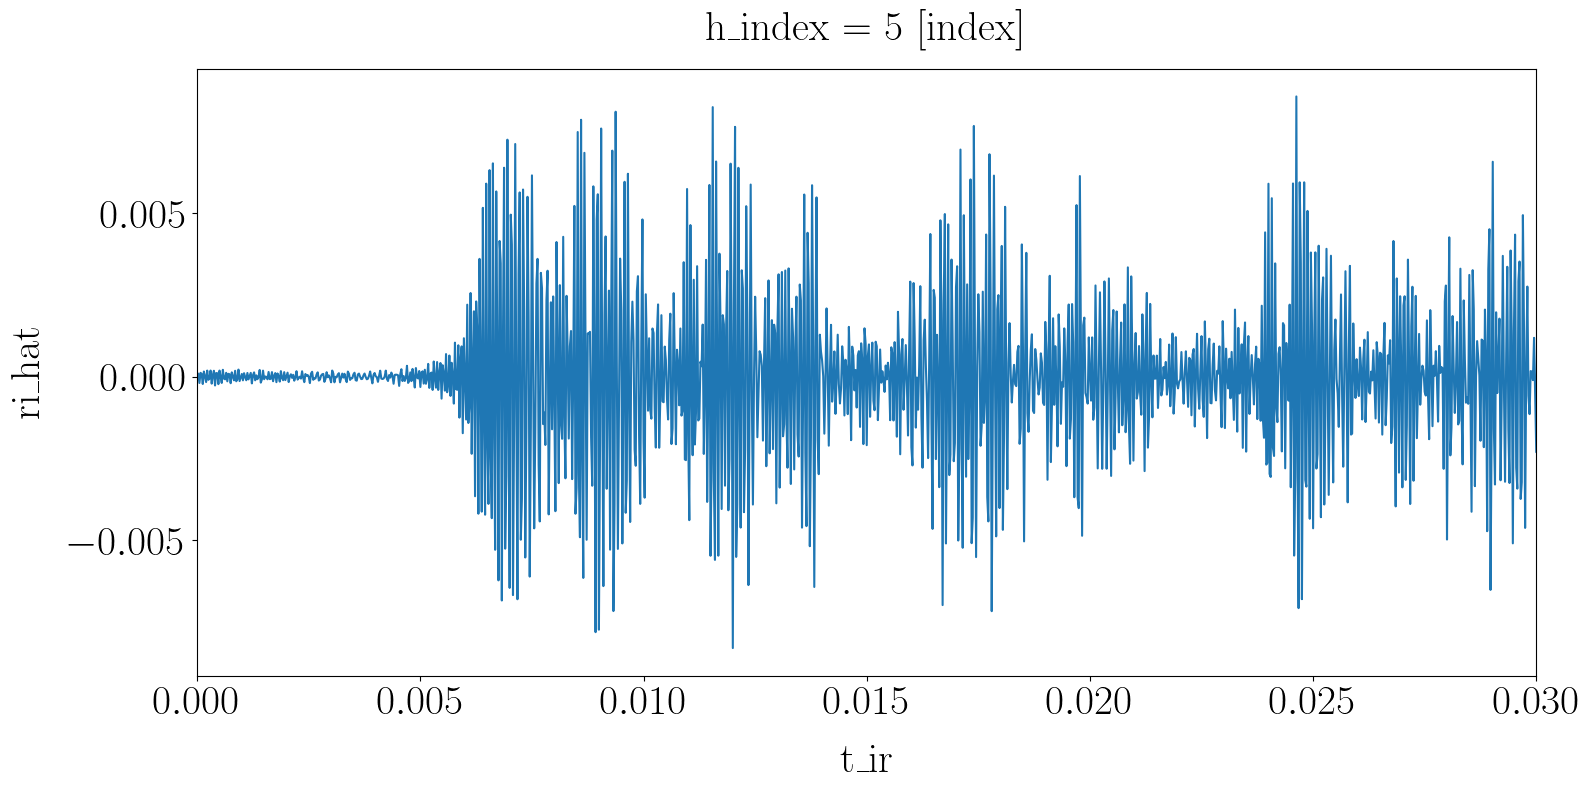

In [11]:
# Calcul des réponses impulsionnelles et analyse
records_to_plot = records_to_process[1:2]
nr = len(records_to_plot)
fig, axs = plt.subplots(nr, 1, sharex=True)
axs = np.atleast_1d(axs)
for irec, record_name in enumerate(records_to_plot):

    ds_rtf_fpath = os.path.join(params.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Plot RIR
    # ds_rtf.ri_hat.plot(ax=axs[irec], label=f"Record {record_name}", hue="h_index")
    ds_rtf.ri_hat.sel(h_index=5).plot(ax=axs[irec], label=f"Record {record_name}", hue="h_index")

    axs[irec].set_xlim([0, 0.03])

### Minimisation en fonction du paramètres $n_{\rm{stft}}$ 

In [12]:
# stop = 

In [13]:
run_minimisation = False

rtf_estimator_minimization = "cs-evd"
# rtf_estimator_minimization = "cs"

fpath = os.path.join(
    params.root_data,
    "test_stft_params",
    f"theta_all_pos_{rtf_estimator_minimization}.nc",
)
tau_ir_0 = params.tau_ir

n_stft_pow2_min = 10
n_stft_pow2_max = int(np.log2(ds_rtf.sizes["time"]))
n_stft_pow2 = np.arange(n_stft_pow2_min, n_stft_pow2_max+1)

ov_factors = [0.5, 0.75, 0.9]


# # # # Test only one configuration
# ov_factors = [0.5, 0.75, 0.9]

# n_stft_pow2_min = 18
# n_stft_pow2_max = int(np.log2(ds_rtf.sizes["time"]))
# n_stft_pow2 = np.arange(n_stft_pow2_min, n_stft_pow2_max+1)


theta_dict = {s_lab : [] for s_lab in src_label_sorted}
if run_minimisation:

    first_iter = True
    fsm = FiberscopeManager(
        root_processed_data=params.root_data,
        h_index_ref=h_index_ref,
        plot_feature=False,
    )

    fs_sweep = FiberscopeSweep1()
    fs_sweep.records_folder = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\test_stft_params\tmp"
    # fs_sweep.records_folder = os.path.join(params.root_data, "static", f"nperseg_2_{n_stft_p2}_ov{int(ov_factor*100)}")
    if not os.path.exists(fs_sweep.records_folder):
        os.makedirs(fs_sweep.records_folder)

    for n_stft_p2 in n_stft_pow2:
        for ov_factor in ov_factors:
            # tau_ir = ir_mult * tau_ir_0

            nperseg = 2**n_stft_p2
            noverlap = int(nperseg * ov_factor)
            fsm.nperseg = nperseg
            fsm.noverlap = noverlap

            # fsm.set_stft_params(ts=ds_rtf.ts)
            print(f"(nperseg = 2**{int(np.log2(fsm.nperseg))}, nov = {fsm.noverlap})")

            # Load and preprocess static recor

            idx_rcv_ref = np.argmin(
                np.abs(ds_rtf.h_index.values - h_index_ref)
            )  # Index of hydrophone might not be sorted or not start at 0
            fsm.set_managers(fs=ds_rtf.fs, idx_rcv_ref=idx_rcv_ref)

            if first_iter : 
                # t0 = time()

                fsm.process_static_analysis(
                    static_signal=fs_sweep,
                    static_records_names=records_to_process,
                    set_stft_props=False,
                    rtf_estimator=rtf_estimator_minimization,
                )

                # Compare RTF estimated by deconvolution and by the RTF estimator (CS or CS-EVD)
                for record_name in records_to_process:

                    ds_rtf_fpath = os.path.join(
                        fs_sweep.records_folder, f"{record_name}_rtf.nc"
                    )
                    ds_rtf = xr.open_dataset(ds_rtf_fpath)

                    # Build RTF ref (from deconvolution)
                    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

                    # Build RTF hat (from CS-EVD)
                    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

                    # Interp RTF ref at RTF hat frequencies (nearest neigbor)
                    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

                    # Compute mean theta distance over the frequency band of interest
                    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

                    # print(f"Record: {record_name}")
                    # print(theta)

                    # Store distance
                    src_pos_label = record_name.split("_")[-4]
                    theta_dict[src_pos_label].append(theta)

                first_iter = False
                # print(f"first iter -> {time() - t0}s")

            else:
                # t0 = time()

                for record_name in records_to_process:      # Avoid re-computing the ref rtf by deconvolution 
                    ds_rtf = fsm.derive_feature(
                        recording_name=record_name,
                        records_folder=fs_sweep.records_folder,
                        signal=fs_sweep,
                        save=False,
                        rtf_estimator=rtf_estimator_minimization,
                    )

                    # Build RTF ref (from deconvolution)
                    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

                    # Build RTF hat (from CS-EVD)
                    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

                    # Interp RTF ref at RTF hat frequencies (nearest neigbor)
                    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

                    # Compute mean theta distance over the frequency band of interest
                    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

                    # print(f"Record: {record_name}")
                    # print(theta)

                    # Store distance
                    src_pos_label = record_name.split("_")[-4]
                    theta_dict[src_pos_label].append(theta)

                # print(f"No deconv iter -> {time() - t0}s")

    # Save
    theta_all_pos = np.array([theta_dict[l] for l in theta_dict.keys()])
    alpha_ovv, n_pow2_pp = np.meshgrid(ov_factors, n_stft_pow2)

    # pos_id is the source position index (sorted by increasing distance)
    # test_id is the index of the STFT parameter test (combination of nperseg and overlap)
    xr_theta = xr.Dataset(
        data_vars=dict(
            theta=(["pos_id", "test_id"], theta_all_pos),
            n_stft_pow2=(["test_id"], n_pow2_pp.flatten()),
            alpha_ov=(["test_id"], alpha_ovv.flatten()),
        ),
        coords=dict(
            pos_id=[int(pl[1]) for pl in theta_dict.keys()],
            test_id=np.arange(n_pow2_pp.size),
        ),
    )

    # Add attributes
    rtf_estimator_minimization_label = rtf_estimator_minimization.upper().replace("-", "_")
    xr_theta.attrs = {
        "description": f"Theta distance between RTF estimated by deconvolution and by {rtf_estimator_minimization_label}, for different STFT parameters",
        "rtf_estimator": rtf_estimator_minimization,
        "h_index_ref": h_index_ref,
        "signal_level": records_to_process[0].split("_")[2],
    }

    xr_theta.to_netcdf(fpath)

else:

    # Load data
    xr_theta = xr.open_dataset(fpath)

In [14]:
# Compute usefull quantities
theta_all_pos = xr_theta.theta.values
theta_mean_over_pos = xr_theta.theta.mean(dim="pos_id").values
theta_med_over_pos = xr_theta.theta.median(dim="pos_id").values
theta_sum_over_pos = xr_theta.theta.sum(dim="pos_id").values

n_stft_pow2 = np.unique(xr_theta.n_stft_pow2.values)
ov_factors = np.unique(xr_theta.alpha_ov.values)

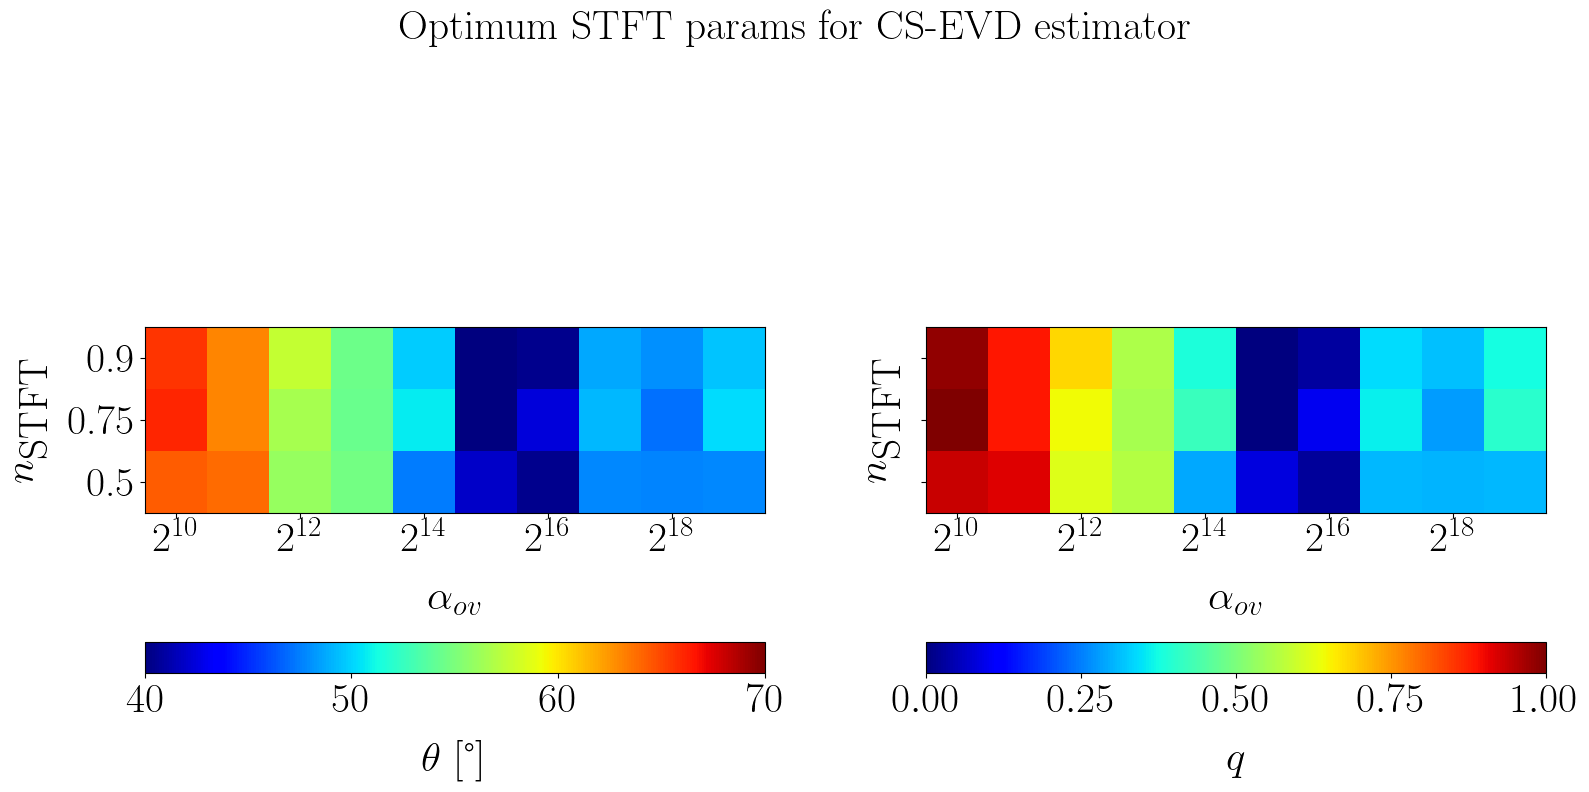

In [15]:
# Plot results
alpha_ovv, n_pow2_pp = np.meshgrid(ov_factors, n_stft_pow2)

theta_surf_mean = theta_mean_over_pos.reshape(n_pow2_pp.shape)
q_mean = normalize_metric_contrast(theta_surf_mean)
q_mean_dB = 10 * np.log10(q_mean + 1e-5)

theta_surf_med = theta_med_over_pos.reshape(n_pow2_pp.shape)
q_med = normalize_metric_contrast(theta_surf_med)

theta_surf_sum = theta_sum_over_pos.reshape(n_pow2_pp.shape)
q_sum = normalize_metric_contrast(theta_surf_sum)

fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True)
# plt.figure()
# im = plt.pcolormesh(alpha_ovv, 2**n_pow2_pp, theta_surf_mean, cmap="jet")
# im = plt.pcolormesh(alpha_ovv, n_pp, q_mean, cmap="jet")
ax = axs[0]
# ax = plt.gca()
# im = ax.imshow(theta_surf_mean.T, cmap="jet", origin="lower")
im = ax.imshow(theta_surf_med.T, cmap="jet", vmin=40, vmax=70, origin="lower")

# ax.set_xticks(np.arange(len(ov_factors)))
# ax.set_xticklabels(ov_factors)
# ax.set_yticks(np.arange(len(n_stft_pow2)))
# ax.set_yticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2])

ax.set_yticks(np.arange(len(ov_factors)))
ax.set_yticklabels(ov_factors)
ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])

# ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
ax.set_xlabel(r"$\alpha_{ov}$")
ax.set_ylabel(r"$n_{\textrm{STFT}}$")
plt.colorbar(ax=ax, mappable=im, label=r"$\theta$ [°]", orientation="horizontal")

# plt.figure()
# im = plt.pcolormesh(alpha_ovv, n_pow2_pp, theta_surf_sum, cmap="jet")
# # im = plt.pcolormesh(alpha_ovv, n_pow2_pp, q_sum, cmap="jet")
# plt.colorbar(im, label=r"$\theta [°]$")
# plt.xlabel(r"$\alpha_{ov}$")
# plt.ylabel("m")

ax = axs[1]
# plt.figure()
# im = plt.pcolormesh(alpha_ovv, n_pow2_pp, theta_surf_mean, cmap="jet")
# im = plt.pcolormesh(alpha_ovv, 2**n_pow2_pp, q_mean, cmap="jet")
# ax = plt.gca()
# im = ax.imshow(q_mean_dB.T, cmap="jet", vmin=-5, vmax=0, origin="lower")
# im = ax.imshow(q_mean.T, cmap="jet", vmin=0, vmax=1, origin="lower")
im = ax.imshow(q_med.T, cmap="jet", vmin=0, vmax=1, origin="lower")

# ax.set_xticks(np.arange(len(ov_factors)))
# ax.set_xticklabels(ov_factors)
# ax.set_yticks(np.arange(len(n_stft_pow2)))
# ax.set_yticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2])

ax.set_yticks(np.arange(len(ov_factors)))
ax.set_yticklabels(ov_factors)
ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])

# ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
ax.set_xlabel(r"$\alpha_{ov}$")
ax.set_ylabel(r"$n_{\textrm{STFT}}$")
plt.colorbar(ax=ax, mappable=im, label=r"$q$", orientation="horizontal")

fig.suptitle(f"Optimum STFT params for {rtf_estimator_minimization.upper()} estimator")
# plt.xlabel(r"$\alpha_{ov}$")
# plt.ylabel(r"$n_{\textrm{STFT}}$")
# plt.yscale("log", base=2)

# Save
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\test_cs_evd_perf\nstft_params"
fpath = os.path.join(root_img, f"{rtf_estimator_minimization}_mean_theta_and_q_over_all_positions.png")
plt.savefig(fpath)

# plt.figure()
# # im = plt.pcolormesh(alpha_ovv, n_pow2_pp, theta_surf_sum, cmap="jet")
# im = plt.pcolormesh(alpha_ovv, n_pow2_pp, q_sum, cmap="jet")
# plt.colorbar(im, label=r"$q$")
# plt.xlabel(r"$\alpha_{ov}$")
# plt.ylabel("m")

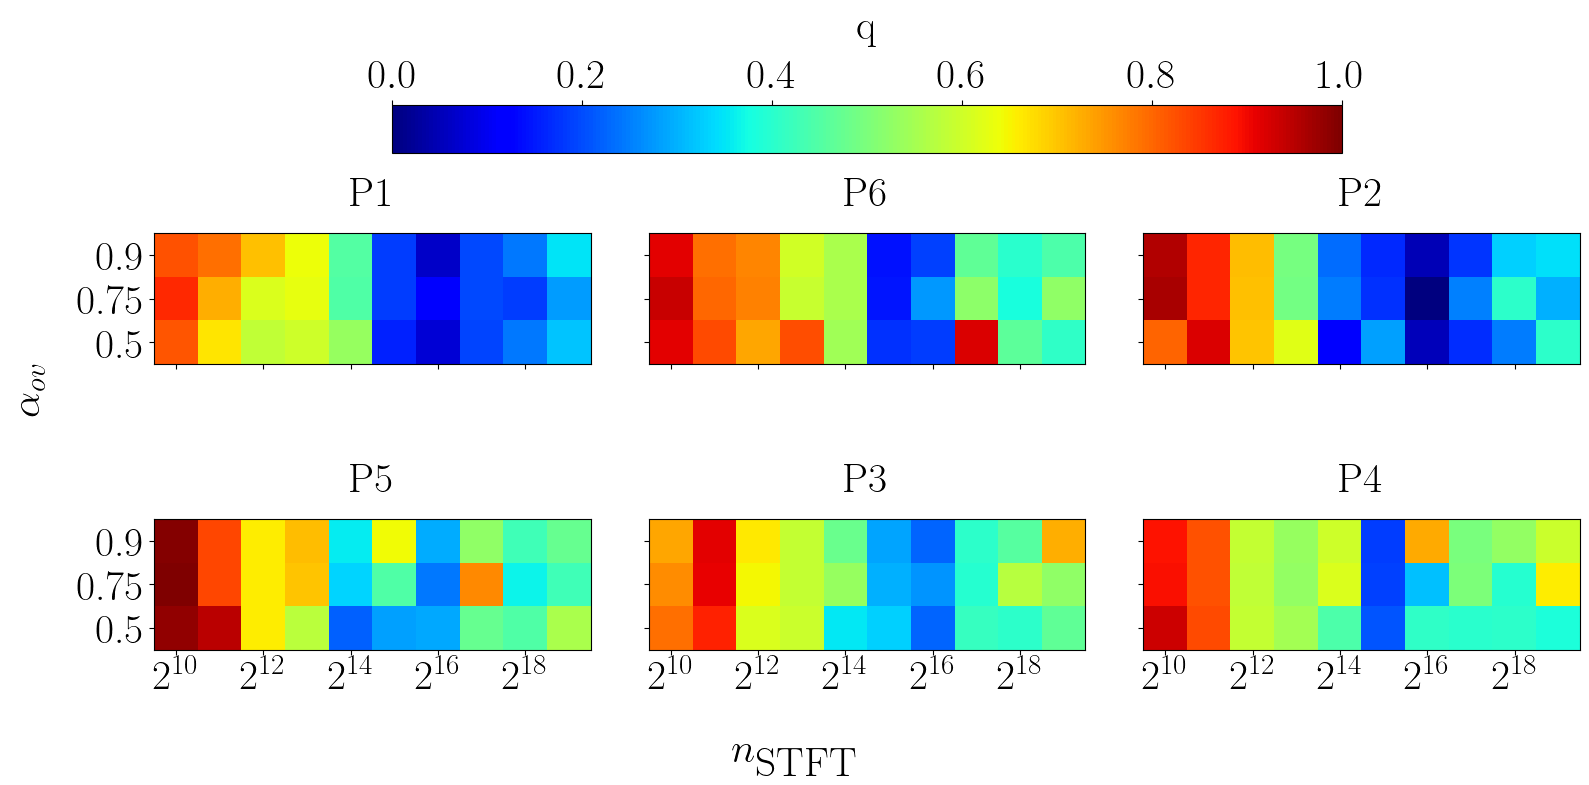

In [16]:
# Plot for each position
q_all_pos = normalize_metric_contrast(theta_all_pos)
fig, axs = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=True)

for ipos, pos in enumerate(src_label_sorted):
    ax = axs[ipos // 3, ipos % 3]
    # theta_pos = np.array(q_all_pos[ipos, :]).reshape(n_pp.shape)
    q_pos = q_all_pos[ipos, :].reshape(n_pow2_pp.shape)
    # q_pos_dB = 10 * np.log10(q_pos + 1e-5)
    # ax.pcolor(alpha_ovv, 2**n_pow2_pp, q_pos, cmap="jet", vmin=0, vmax=1, shading="nearest")
    # im = ax.imshow(q_pos_dB.T, cmap="jet", vmin=-10, vmax=0, origin="lower")

    im = ax.imshow(q_pos.T, cmap="jet", vmin=0, vmax=1, origin="lower")
    # ax.set_aspect("equal")
    # ax.set_xticks(np.arange(len(ov_factors)))
    # ax.set_xticklabels(ov_factors)
    # ax.set_yticks(np.arange(len(n_stft_pow2)))
    # ax.set_yticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2])

    ax.set_yticks(np.arange(len(ov_factors)))
    ax.set_yticklabels(ov_factors)
    ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
    ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])

    # ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
    # ax.set_xlabel(r"$\alpha_{ov}$")
    # ax.set_ylabel(r"$n_{\textrm{STFT}}$")
    # ax.set_yscale("log", base=2)
    ax.set_title(pos)

# fig.colorbar(im, )
# fig.subplots_adjust(right=0.8)
# cbar_ax = fig.add_axes([1., 0.15, 0.03, 0.7])
# cbar_ax = fig.add_axes([0.15, 0.1, 0.7, 0.03])
# fig.colorbar(im, cax=cbar_ax, label="q", orientation="horizontal")
fig.colorbar(
    im, ax=axs, orientation="horizontal", fraction=0.1, location="top", label="q"
)

# fig.supxlabel(r"$\alpha_{ov}$")
# fig.supylabel(r"$n_{\textrm{STFT}}$")
fig.supylabel(r"$\alpha_{ov}$")
fig.supxlabel(r"$n_{\textrm{STFT}}$")

# Save
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\test_cs_evd_perf\nstft_params"
fpath = os.path.join(root_img, f"{rtf_estimator_minimization}_q_each_position.png")
plt.savefig(fpath)

## Bilan etape 1 : 

Le couple de paramètres optimaux pour l'estimation des RTFs correspondant aux positions statiques P1 à P6 de la source est :

$n_{\rm{stft}} = 2^{15}$ et $\alpha_{\rm{ov}} = 0.75$

On peut note néanmoins une forte variabilité en fonction de la position de la source considérée. 

De plus, il est important de noter que ce couple de paramètres optimaux est optimal pour la taille des signaux considérés : 10 émissions = 10 secondes + 4.6 s de silence -> 14.6 s. 

Ainsi, ce couple n'est pas nécessairement optimal dans le cas du signal de la source en mouvement pour lequel on souhaite analyser des plus petits segments de signal (typiquement 3 émissions) = 3 s. 


Le nombre de segments L dispo est donné par 

L = (T * fs - n_stft + alpha_ov * n_stft) / (alpha_ov * n_stft)  

Si l'on souhaite garder à approximativement le même nombre de segments on peut utiliser :

nstft_dyn = (T_dyn * fs) / (1 + alpha_ov_opti * (L_stat - 1))


# Etape 2 : localisation RTF-MFP

In [91]:
ds_rtf = xr.open_dataset(
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\dynamic\10-10-2024T16-53-43-200271_PR_N1_346.nc"
)
fs = ds_rtf.fs

In [92]:
ns_opti = 2**16  # Pour cs
# ns_opti = 2**15 # Pour cs_evd

print(f"T_stst = {ns_opti * 1/fs} s" )
print(f"Distance parcourue en T_stft, d_stft = {ns_opti * 1/fs * 1500} m")
print(f"Equivelent en nombre de réflexion fond surface nref = d_stft / 2H = {ns_opti * 1/fs * 1500 / 20}")

alpha_ov_opti = 0.75

T_stat = 14.6
T_dyn = 3       # Par exemple 

def L_available_seg(T, fs, n_stft, alpha_ov):
    L = (T * fs - n_stft + alpha_ov * n_stft) / (alpha_ov * n_stft) 
    return np.floor(L) 

L_dyn = L_available_seg(T=T_dyn, fs=fs, n_stft=ns_opti, alpha_ov=alpha_ov_opti) 
L_stat = L_available_seg(T=T_stat, fs=fs, n_stft=ns_opti, alpha_ov=alpha_ov_opti)

print(f"L_dyn = {L_dyn}")
print(f"L_stat = {L_stat}")

def n_stft_dyn_cst_L(T, fs, L_ref, alpha_ov_ref):
    n_cst_L = (T * fs) / (1 + alpha_ov_ref * (L_ref - 1))
    n_stft_cst_L = 2 ** (np.floor(np.log2(n_cst_L)) + 1)
    return n_stft_cst_L

n_stft_dyn = n_stft_dyn_cst_L(T=T_dyn, fs=ds_rtf.fs, L_ref=L_stat, alpha_ov_ref=alpha_ov_opti)
print(f"n_stft for dynamic recording : 2**{np.log2(n_stft_dyn)}")

print(f"T_stst = {n_stft_dyn * 1/fs} s")
print(f"Distance parcourue en T_stft, d_stft = {n_stft_dyn * 1/fs * 1500} m")
print(
    f"Equivalent en nombre de réflexion fond surface nref = d_stft / 2H = {n_stft_dyn * 1/fs * 1500 / 20}"
)

T_stst = 1.6383999999999865 s
Distance parcourue en T_stft, d_stft = 2457.59999999998 m
Equivelent en nombre de réflexion fond surface nref = d_stft / 2H = 122.879999999999
L_dyn = 2.0
L_stat = 11.0
n_stft for dynamic recording : 2**14.0
T_stst = 0.40959999999999663 s
Distance parcourue en T_stft, d_stft = 614.399999999995 m
Equivelent en nombre de réflexion fond surface nref = d_stft / 2H = 30.71999999999975


In [93]:
# Define usefull paths

# Raw data
tdms_data_root = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\Fiberscope_campagne_oct_2024"
)

# Folder to save results
img_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\dynamic_src_localization_rtf_mfp"
root_data_dyn = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\dynamic"

if not os.path.exists(img_root):
    os.makedirs(img_root)
if not os.path.exists(root_data_dyn):
    os.makedirs(root_data_dyn)

In [94]:
fs_dynamic = FiberscopeDynamicRecording()

## Chargement des signaux 

In [95]:
load_tdms_data = False

if load_tdms_data:

    date = fs_dynamic.recording_name.split("T")[0]
    data_path = os.path.join(tdms_data_root, f"Campagne_{date}")
    file_name = f"{fs_dynamic.recording_name}.tdms"
    file_path = os.path.join(data_path, file_name)

    data = load_fiberscope_data(file_path, subsampling_factor=5)

    # Save data as netcdf
    data.to_netcdf(os.path.join(root_data_dyn, f"{fs_dynamic.recording_name}.nc"))

else: 
    # Load pre-saved data
    data = xr.load_dataset(
        os.path.join(root_data_dyn, f"{fs_dynamic.recording_name}.nc")
    )

In [96]:
data

<xarray.Dataset> Size: 527MB
Dimensions:  (h_index: 5, time: 10984000)
Coordinates:
  * h_index  (h_index) int32 20B 1 2 3 4 5
  * time     (time) float64 88MB 0.0 2.5e-05 5e-05 7.5e-05 ... 274.6 274.6 274.6
Data variables:
    signal   (h_index, time) float64 439MB 0.001352 -0.003773 ... -0.003987
Attributes:
    Freq. ech:         200000,000000
    Freq. ech. Unité:  Hz
    Gamme:             1
    Gamme Unité:       V
    wf_increment:      4.999999999999959e-06
    wf_start_offset:   0.0
    wf_samples:        1
    wf_start_time:     2024-10-10 14:53:43.200271
    ts:                2.4999999999999795e-05
    fs:                40000.00000000033

### Définition des segments à analyser succesivement 

In [97]:
# Choix du pas de temps pour le découpage du signal c'est important
time_step =  1 # s
n_sweep_step = int(time_step / fs_dynamic.signal.interp_pulse_period)

# Mise à jour des paramètres stft à utiliser en fonction du pas de temps
n_stft_dyn = n_stft_dyn_cst_L(
    T=time_step, fs=data.fs, L_ref=L_stat, alpha_ov_ref=alpha_ov_opti
)

# n_stft_dyn = 2**15
n_stft_dyn = n_stft_dyn
alpha_ov_dyn = alpha_ov_opti
print(f"n_stft for dynamic recording : 2**{np.log2(n_stft_dyn)}")


n_stft for dynamic recording : 2**13.0


In [98]:
# Create an instance of FiberscopeManager
root_processed_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\dynamic"
fsm = FiberscopeManager(
    root_processed_data=root_processed_data,
    h_index_ref=h_index_ref,
    plot_feature=True,
)

In [99]:
# Load and preprocess static record
# root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data"
fs_sweep1 = FiberscopeSweep1()
fs_sweep1.records_folder = os.path.join(root_data_dyn, "static_to_loc")
if not os.path.exists(fs_sweep1.records_folder):
    os.makedirs(fs_sweep1.records_folder)

# Set stft params for static records
# nperseg = ns_opti
# noverlap = int(nperseg * alpha_ov_opti)
# fsm.nperseg = nperseg
# fsm.noverlap = noverlap
nperseg = n_stft_dyn
noverlap = int(nperseg * alpha_ov_dyn)
fsm.nperseg = nperseg
fsm.noverlap = noverlap

print(f"(nperseg = 2**{int(np.log2(fsm.nperseg))}, nov = {fsm.noverlap})")

(nperseg = 2**13, nov = 6144)


In [100]:
rtf_estimator_static = "cs"
# rtf_estimator_static = "cs-evd"

fsm.process_static_analysis(
    static_signal=fs_sweep1,
    static_records_names=fs_sweep1.records_N1,
    set_stft_props=False,
    rtf_estimator=rtf_estimator_static,
)

In [101]:

# # preSplit the dynamic recording
fsm.presplit_dynamic_record(
    fs_dynamic_recording=fs_dynamic,
    n_sweep=n_sweep_step,
    t_max=np.max(data.time.values),
)

In [102]:
fs_dynamic.splitted_records_folder


'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\real_data_analysis\\fiberscope_20\\data\\dynamic\\dynamic_1pulses'

In [103]:
# fs_dynamic.splitted_records_names

### Séparation du signal en plusieurs segments

In [105]:
#  Split dynamic records and save as nc
fsm.split_dynamic_record(fs_dynamic_recording=fs_dynamic, force_reload=True)


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\real_data_analysis\\fiberscope_20\\data\\dynamic\\dynamic_1pulses\\10-10-2024T16-53-43-200271_PR_N1_346_P1_r27.05m_P4.nc'

In [ ]:
# Derive features
# rtf_estimator_dyn = "cs-evd"
rtf_estimator_dyn = "cs"
fsm.plot_feature = False 

fsm.process_dyn_analysis(
    fs_dynamic_recording=fs_dynamic,
    use_global_noise_csdm=False,
    set_stft_props=False,
    rtf_estimator=rtf_estimator_dyn,
)

C:\Users\baptiste.menetrier\Desktop\devPy\phd\source\cov_manager.py:226: RuntimeWarning: invalid value encountered in divide
  np.einsum("ftr,fts->frs", stft_block, stft_block_conj) / n_mean
C:\Users\baptiste.menetrier\Desktop\devPy\phd\source\rtf_estimator.py:287: RuntimeWarning: invalid value encountered in divide
  rtf = clean_signal_csdm_e1 / (clean_signal_csdm_e11[:, np.newaxis])


In [ ]:

# Run localization process
d = fsm.localize_dyn_recording(
    static_signal=fs_sweep1,
    static_records_names=fs_sweep1.records_N1,
    fs_dynamic_recording=fs_dynamic,
)

C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_utils.py:210: RuntimeWarning: Mean of empty slice
  dist = np.nanmean(dist)
C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_utils.py:210: RuntimeWarning: Mean of empty slice
  dist = np.nanmean(dist)
C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_utils.py:210: RuntimeWarning: Mean of empty slice
  dist = np.nanmean(dist)
C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_utils.py:210: RuntimeWarning: Mean of empty slice
  dist = np.nanmean(dist)
C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_utils.py:210: RuntimeWarning: Mean of empty slice
  dist = np.nanmean(dist)
C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_utils.py:210: RuntimeWarning: Mean of empty slice
  dist = np.nanmean(dist)


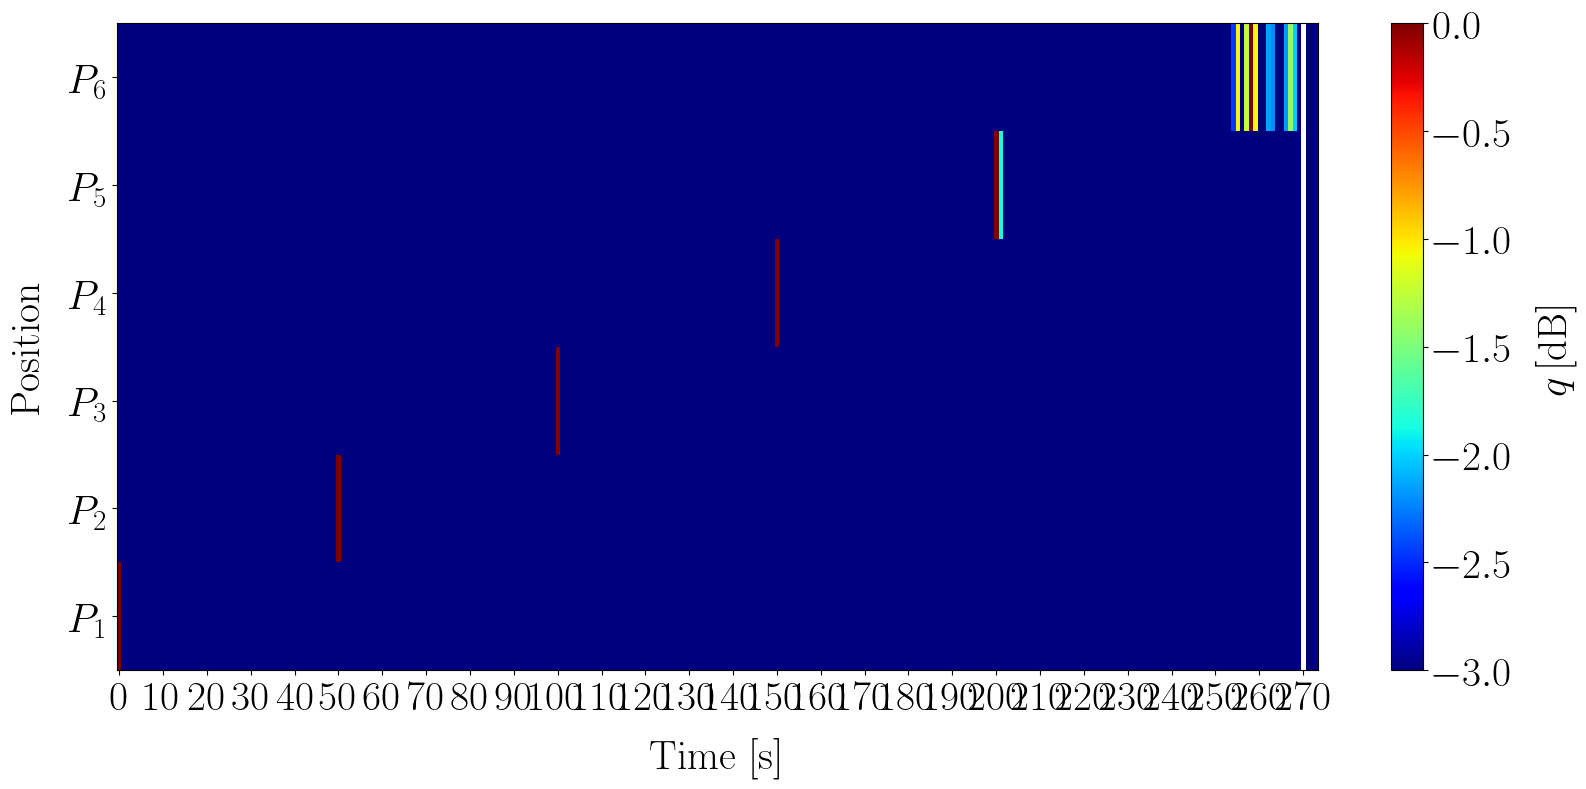

In [83]:
fsm.plot_dyn_loc(
    d_rtf=d, axis_norm=1, time_step=fs_dynamic.time_step, vmin=-3, save_eps=False
)
# Save
img_dir = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localization\rtf_mfp"
fpath = os.path.join(img_dir, f"{rtf_estimator_dyn}_ambiguity_surface_q_href{h_index_ref}_nperseg{fsm.nperseg}.png")
plt.savefig(fpath)

In [84]:
# d_save = 
dict_th_pos

{'P1': 0, 'P2': 10, 'P3': 20, 'P4': 25, 'P5': 15, 'P6': 5}

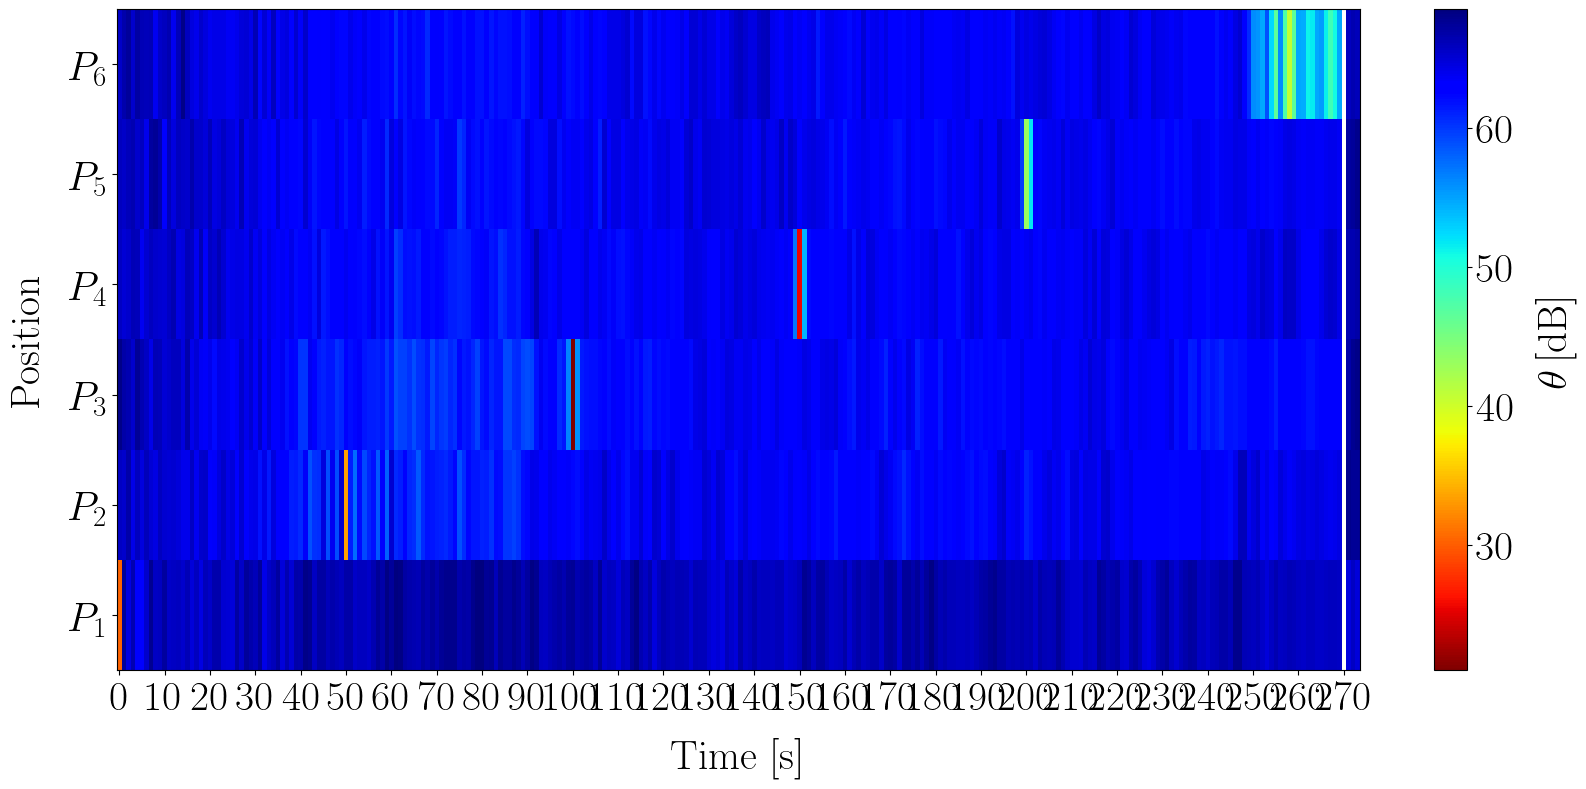

In [85]:
# d = d_save
axis_norm = 1
if axis_norm is None:
    d_max = np.max(d, axis=axis_norm) * np.ones_like(d)
    d_min = np.min(d, axis=axis_norm) * np.ones_like(d)
    norm_label = "norm_over_entire_surface"
else:
    d_max = np.tile(
        np.max(d, axis=axis_norm), (d.shape[axis_norm], 1)
    )  # Cast to d shape
    d_min = np.tile(np.min(d, axis=axis_norm), (d.shape[axis_norm], 1))
    if axis_norm == 1:
        norm_label = f"norm_along_time_axis"
    elif axis_norm == 0:
        norm_label = f"norm_along_position_axis"

if axis_norm == 1:
    d_max = d_max.T
    d_min = d_min.T


t = np.arange(0, d.shape[1]) * time_step
ordered_pos = [f"$P_{i}$" for i in range(1, 7)]
truepos_order = [0, 5, 1, 4, 2, 3]
d = d[truepos_order, :]
plt.figure()
plt.imshow(d, cmap="jet_r", aspect="auto", rasterized=False)
plt.xticks(np.arange(0, d.shape[1], 10), np.round(t[::10], 2))
plt.yticks(np.arange(0, d.shape[0]), ordered_pos)
plt.xlabel("Time [s]")
plt.ylabel("Position")
plt.colorbar(label=r"$\theta\, \textrm{[dB]}$")
plt.gca().invert_yaxis()

# Save
img_dir = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localization\rtf_mfp"
fpath = os.path.join(
    img_dir,
    f"{rtf_estimator_dyn}_ambiguity_surface_theta_href{h_index_ref}_nperseg{fsm.nperseg}.png",
)
plt.savefig(fpath)
# # Normalize
# q = (d - d_min) / (d_max - d_min)

# # In dB
# q[q == 0] = 1e-6
# q_dB = 10 * np.log10(q)

### CS-EVD

In [86]:
rtf_estimator_static = "cs-evd"

fsm.process_static_analysis(
    static_signal=fs_sweep1,
    static_records_names=fs_sweep1.records_N1,
    set_stft_props=False,
    rtf_estimator=rtf_estimator_static,
)

In [87]:
# # preSplit the dynamic recording
fsm.presplit_dynamic_record(
    fs_dynamic_recording=fs_dynamic,
    n_sweep=n_sweep_step,
    t_max=np.max(data.time.values),
)

In [88]:
fs_dynamic.splitted_records_folder


'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\real_data_analysis\\fiberscope_20\\data\\dynamic\\dynamic_1pulses'

In [89]:
#  Split dynamic records and save as nc
fsm.split_dynamic_record(fs_dynamic_recording=fs_dynamic, force_reload=True)


In [90]:
# Derive features
rtf_estimator_dyn = "cs-evd"
fsm.plot_feature = False 

fsm.process_dyn_analysis(
    fs_dynamic_recording=fs_dynamic,
    use_global_noise_csdm=False,
    set_stft_props=False,
    rtf_estimator=rtf_estimator_dyn,
)

C:\Users\baptiste.menetrier\Desktop\devPy\phd\source\cov_manager.py:226: RuntimeWarning: invalid value encountered in divide
  np.einsum("ftr,fts->frs", stft_block, stft_block_conj) / n_mean


ValueError: Variable 'rtf_amp_hat': Could not convert tuple of form (dims, data[, attrs, encoding]): (['h_index', 'f_rtf'], array([], shape=(0, 5, 4097), dtype=float64)) to Variable.

In [ ]:
# Run localization process
d = fsm.localize_dyn_recording(
    static_signal=fs_sweep1,
    static_records_names=fs_sweep1.records_N1,
    fs_dynamic_recording=fs_dynamic,
)

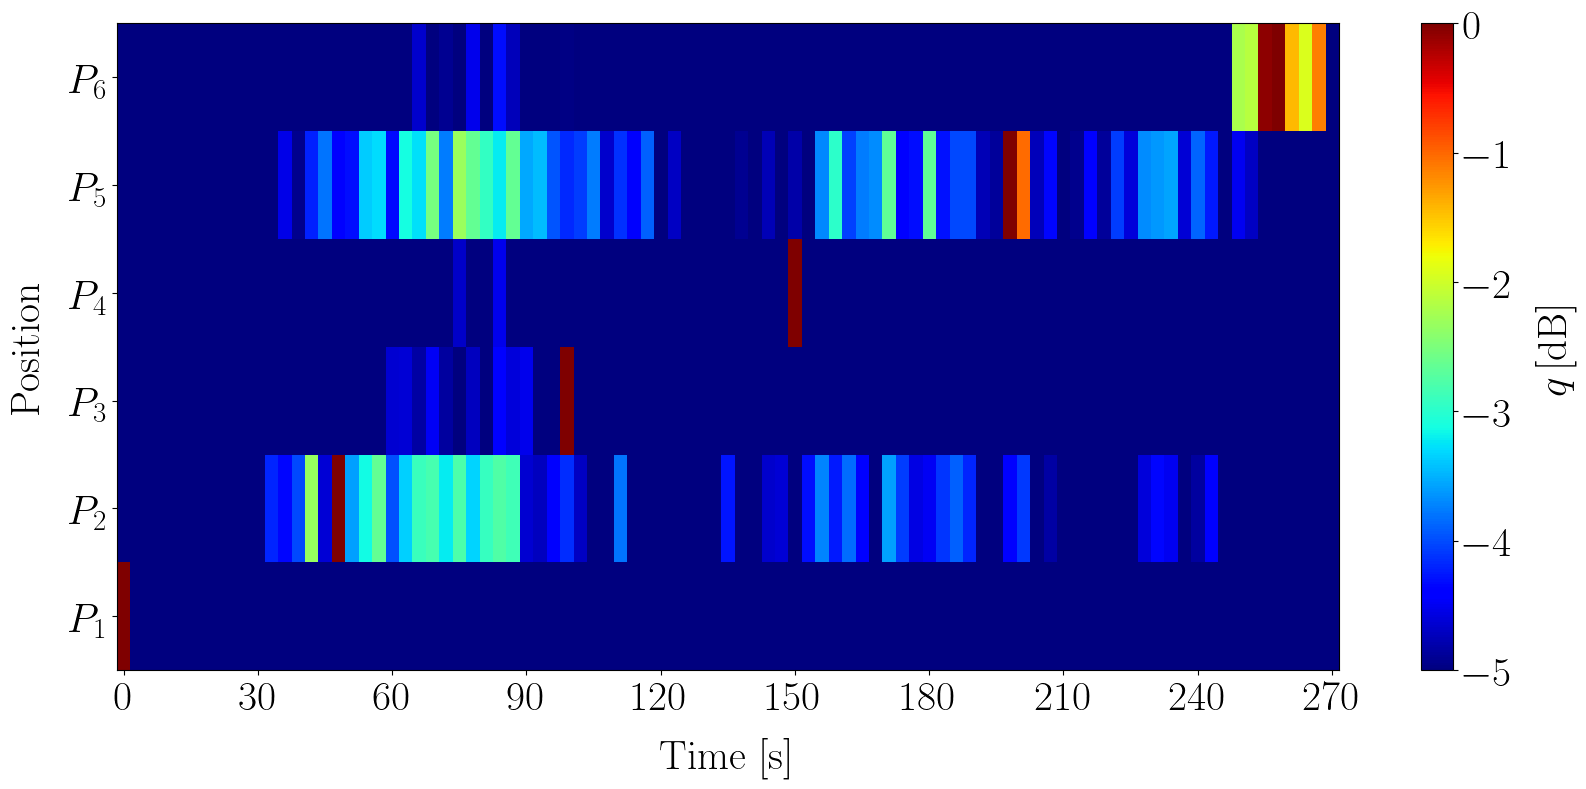

In [ ]:
fsm.plot_dyn_loc(
    d_rtf=d, axis_norm=1, time_step=fs_dynamic.time_step, vmin=-5, save_eps=False
)
# Save
img_dir = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localization\rtf_mfp"
fpath = os.path.join(img_dir, f"{rtf_estimator_dyn}_ambiguity_surface_q_href{h_index_ref}_nperseg{fsm.nperseg}.png")
plt.savefig(fpath)

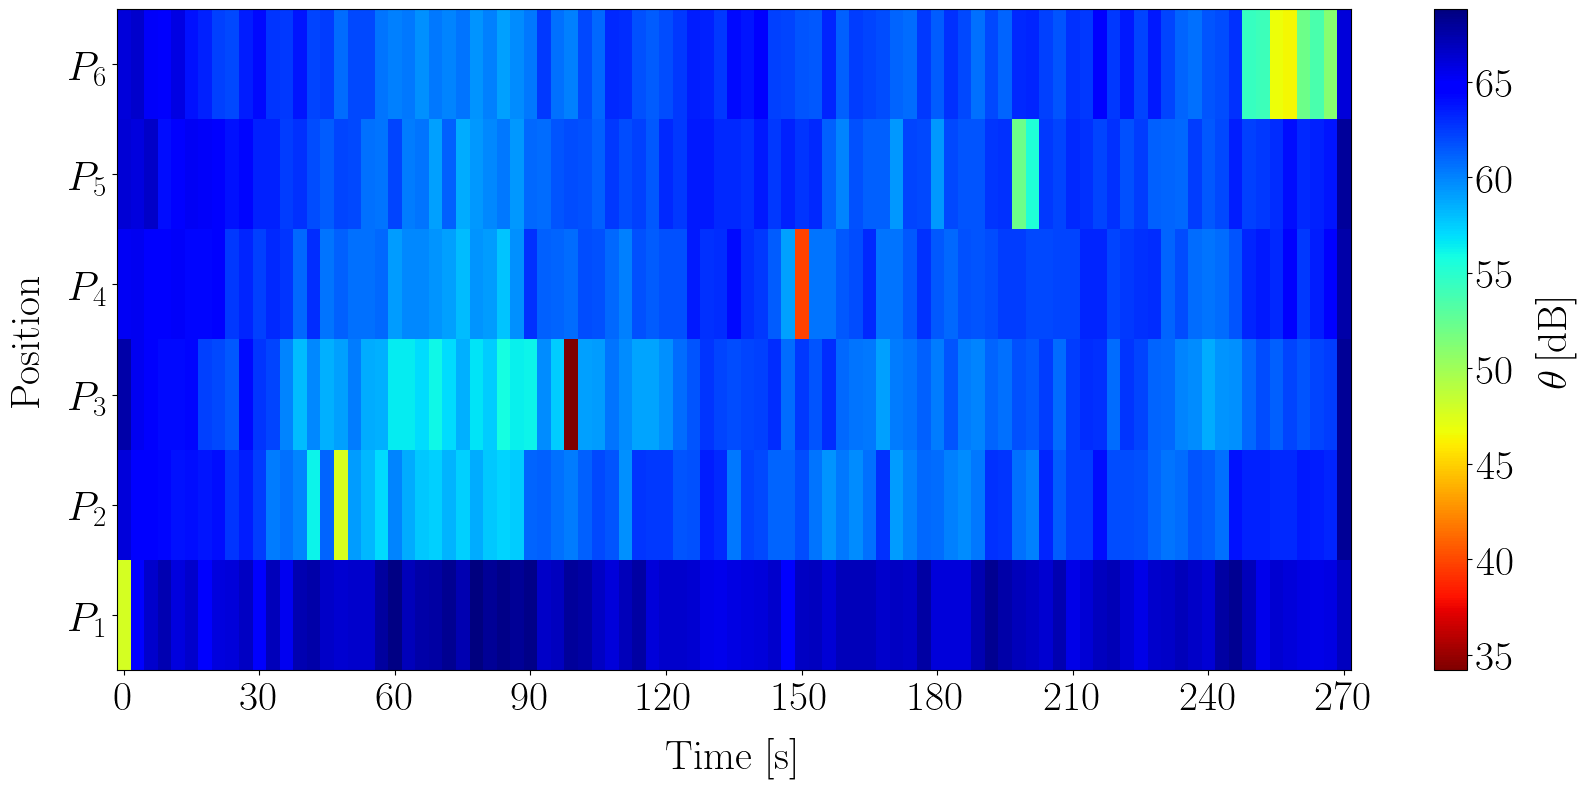

In [ ]:
# d = d_save
axis_norm = 1
if axis_norm is None:
    d_max = np.max(d, axis=axis_norm) * np.ones_like(d)
    d_min = np.min(d, axis=axis_norm) * np.ones_like(d)
    norm_label = "norm_over_entire_surface"
else:
    d_max = np.tile(
        np.max(d, axis=axis_norm), (d.shape[axis_norm], 1)
    )  # Cast to d shape
    d_min = np.tile(np.min(d, axis=axis_norm), (d.shape[axis_norm], 1))
    if axis_norm == 1:
        norm_label = f"norm_along_time_axis"
    elif axis_norm == 0:
        norm_label = f"norm_along_position_axis"

if axis_norm == 1:
    d_max = d_max.T
    d_min = d_min.T


t = np.arange(0, d.shape[1]) * time_step
ordered_pos = [f"$P_{i}$" for i in range(1, 7)]
truepos_order = [0, 5, 1, 4, 2, 3]
d = d[truepos_order, :]
plt.figure()
plt.imshow(d, cmap="jet_r", aspect="auto", rasterized=False)
plt.xticks(np.arange(0, d.shape[1], 10), np.round(t[::10], 2))
plt.yticks(np.arange(0, d.shape[0]), ordered_pos)
plt.xlabel("Time [s]")
plt.ylabel("Position")
plt.colorbar(label=r"$\theta\, \textrm{[dB]}$")
plt.gca().invert_yaxis()

# Save
img_dir = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localization\rtf_mfp"
fpath = os.path.join(
    img_dir,
    f"{rtf_estimator_dyn}_ambiguity_surface_theta_href{h_index_ref}_nperseg{fsm.nperseg}.png",
)
plt.savefig(fpath)
# # Normalize
# q = (d - d_min) / (d_max - d_min)

# # In dB
# q[q == 0] = 1e-6
# q_dB = 10 * np.log10(q)

In [ ]:
# Plot rtf at a given position to compare RTF static and dynamic
pos_to_study = "P1"

# Extract ranges corresponding to each splitted record
splitted_record_ranges = [float(fname.split("_")[-2].split("r")[1].split("m")[0]) for fname in fs_dynamic.splitted_records_names]
# Find the record that is the closest to each theoretical position
idx = np.argmin(np.abs(np.array(splitted_record_ranges) - dict_th_pos[pos_to_study]))
# idx = -2
records_close_to_static_pos = fs_dynamic.splitted_records_names[idx] 

fmin = 10000
fmax = 11000
# Load dynamic record
ds_dyn = xr.load_dataset(
    os.path.join(fs_dynamic.splitted_records_folder, f"{records_close_to_static_pos}_rtf.nc")
)
ds_dyn = ds_dyn.sel(f_rtf=slice(fmin, fmax))

records_close_to_static_pos_plusone = fs_dynamic.splitted_records_names[max(idx+1, len(fs_dynamic.splitted_records_names)-1)] 
ds_dyn_plusone = xr.load_dataset(
    os.path.join(
        fs_dynamic.splitted_records_folder,
        f"{records_close_to_static_pos_plusone}_rtf.nc",
    )
)
ds_dyn_plusone = ds_dyn_plusone.sel(f_rtf=slice(fmin, fmax))

records_close_to_static_pos_minusone = fs_dynamic.splitted_records_names[max(idx-1, 0)]
ds_dyn_minusone = xr.load_dataset(
    os.path.join(
        fs_dynamic.splitted_records_folder,
        f"{records_close_to_static_pos_minusone}_rtf.nc",
    )
)
ds_dyn_minusone = ds_dyn_minusone.sel(f_rtf=slice(fmin, fmax))

# Load static record
stat_record_name = [fname for fname in fs_sweep1.records_N1 if pos_to_study in fname][0]
ds_stat = xr.load_dataset(
    os.path.join(fs_sweep1.records_folder, f"{stat_record_name}_rtf.nc")
)
ds_stat = ds_stat.sel(f_rtf=slice(fmin, fmax))
ds_stat = ds_stat.sel(f_ir=slice(fmin, fmax))

# Plot RTF for each receiver
# nl = ds_stat.sizes["h_index"]
nl = 2
fig_amp, axs_amp = plt.subplots(nl, 1, sharex=True)
fig_amp.suptitle(f"Record: {stat_record_name} - Amplitude")
fig_phase, axs_phase = plt.subplots(nl, 1, sharex=True)
fig_phase.suptitle(f"Record: {stat_record_name} - Phase")

# Plot for each receiver
for i, idx_rcv in enumerate(ds_stat.h_index.values[0:nl]):

    ## Amplitudes ##
    # Plot ref rtf from static record (deconvolution)
    ds_stat.rtf_amp.sel(h_index=idx_rcv).plot(
        ax=axs_amp[i], color="k", label=f"Ref-static-deconvolution {idx_rcv}"
    )
    # Plot CS-EVD rtf from static record
    ds_stat.rtf_amp_hat.sel(h_index=idx_rcv).plot(
        ax=axs_amp[i],
        color="g",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-static-CSEVD - {idx_rcv}",
    )

    # Plot CS-EVD rtf from dynamic records
    ds_dyn.rtf_amp_hat.sel(h_index=idx_rcv).plot(
        ax=axs_amp[i],
        color="r",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS - {idx_rcv}",
    )

    # Plot CS-EVD rtf from dynamic records plus one
    ds_dyn_plusone.rtf_amp_hat.sel(h_index=idx_rcv).plot(
        ax=axs_amp[i],
        color="orange",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS+1 - {idx_rcv}",
    )
    # Plot CS-EVD rtf from dynamic records minus one
    ds_dyn_minusone.rtf_amp_hat.sel(h_index=idx_rcv).plot(
        ax=axs_amp[i],
        color="purple",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS-1 - {idx_rcv}",
    )

    axs_amp[i].set_xlabel("")
    axs_amp[i].set_ylabel(r"$|\Pi|$")
    axs_amp[i].set_yscale("log")
    axs_amp[i].set_title("")
    axs_amp[i].legend(fontsize=8)
    axs_amp[i].vlines(10198, -1, 1)

    # Plot RTF phase
    ds_stat.rtf_phase.sel(h_index=idx_rcv).plot(
        ax=axs_phase[i], color="k", label=f"Ref-static-deconvolution - {idx_rcv}"
    )

    # Plot CS-EVD rtf from static record
    ds_stat.rtf_phase_hat.sel(h_index=idx_rcv).plot(
        ax=axs_phase[i],
        color="g",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-static-CSEVD - {idx_rcv}",
    )

    # Plot CS-EVD rtf from dynamic records
    ds_dyn.rtf_phase_hat.sel(h_index=idx_rcv).plot(
        ax=axs_phase[i],
        color="r",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS - {idx_rcv}",
    )

    axs_phase[i].set_xlabel("")
    axs_phase[i].set_ylabel(r"$\Phi$")
    axs_phase[i].set_title("")
    axs_phase[i].legend()
    axs_phase[i].legend(fontsize=8)


# Compute distance between static and dynamic RTF
rtf_stat = ds_stat.rtf_amp_hat * np.exp(
    1j * ds_stat.rtf_phase_hat
)
rtf_dyn = ds_dyn.rtf_amp_hat * np.exp(1j * ds_dyn.rtf_phase_hat)

theta_stat_dyn = dist_func(rtf_ref=rtf_stat.values, rtf=rtf_dyn.values, **dist_kwargs)
print(f"Theta distance between static and dynamic RTF at {pos_to_study} : {theta_stat_dyn}°")

# Distance plus one 
rtf_dyn_plusone = ds_dyn_plusone.rtf_amp_hat * np.exp(1j * ds_dyn_plusone.rtf_phase_hat)
theta_stat_dyn_plusone = dist_func(rtf_ref=rtf_stat.values, rtf=rtf_dyn_plusone.values, **dist_kwargs)
print(f"Theta distance between static and dynamic+1 RTF at {pos_to_study} : {theta_stat_dyn_plusone}°")

# Distance minus one
rtf_dyn_minusone = ds_dyn_minusone.rtf_amp_hat * np.exp(1j * ds_dyn_minusone.rtf_phase_hat)
theta_stat_dyn_minusone = dist_func(rtf_ref=rtf_stat.values, rtf=rtf_dyn_minusone.values, **dist_kwargs)
print(f"Theta distance between static and dynamic-1 RTF at {pos_to_study} : {theta_stat_dyn_minusone}°")

In [ ]:
# Visualisation des vecteurs de RTFs dans le plan complexe (ie à une fréquence donnée)
f_visu = 10190
ds_stat_f = ds_stat.sel(f_rtf=f_visu, method="nearest")
ds_dyn_f = ds_dyn.sel(f_rtf=f_visu, method="nearest")
ds_dyn_plusone_f = ds_dyn_plusone.sel(f_rtf=f_visu, method="nearest")
ds_dyn_minusone_f = ds_dyn_minusone.sel(f_rtf=f_visu, method="nearest")
plt.figure()
plt.plot(
    ds_stat_f.rtf_amp_hat * np.cos(ds_stat_f.rtf_phase_hat),
    ds_stat_f.rtf_amp_hat * np.sin(ds_stat_f.rtf_phase_hat),
    "-o",
    label="Static-CS",
)
plt.plot(
    ds_dyn_f.rtf_amp_hat * np.cos(ds_dyn_f.rtf_phase_hat),
    ds_dyn_f.rtf_amp_hat * np.sin(ds_dyn_f.rtf_phase_hat),
    "-o",
    label="Dyn-CS",
)
plt.plot(
    ds_dyn_plusone_f.rtf_amp_hat * np.cos(ds_dyn_plusone_f.rtf_phase_hat),
    ds_dyn_plusone_f.rtf_amp_hat * np.sin(ds_dyn_plusone_f.rtf_phase_hat),
    "-o",
    label="Dyn-CS+1",
)
plt.plot(
    ds_dyn_minusone_f.rtf_amp_hat * np.cos(ds_dyn_minusone_f.rtf_phase_hat),
    ds_dyn_minusone_f.rtf_amp_hat * np.sin(ds_dyn_minusone_f.rtf_phase_hat),
    "-o",
    label="Dyn-CS-1",
)
plt.legend()

In [ ]:
# Exact same plots but to look at real and imag parts of the RTF
rtf_stat_real = np.real(rtf_stat)
rtf_stat_imag = np.imag(rtf_stat)
rtf_dyn_real = np.real(rtf_dyn)
rtf_dyn_imag = np.imag(rtf_dyn)
rtf_dyn_plusone_real = np.real(rtf_dyn_plusone)
rtf_dyn_plusone_imag = np.imag(rtf_dyn_plusone)
rtf_dyn_minusone_real = np.real(rtf_dyn_minusone)
rtf_dyn_minusone_imag = np.imag(rtf_dyn_minusone)

# Plot RTF for each receiver
# nl = ds_stat.sizes["h_index"]
nl = 2
fig_real, axs_real = plt.subplots(nl, 1, sharex=True)
fig_real.suptitle(f"Record: {stat_record_name} - Real part of RTF")
fig_imag, axs_imag = plt.subplots(nl, 1, sharex=True)
fig_imag.suptitle(f"Record: {stat_record_name} - Imag part of RTF")
# Plot for each receiver
for i, idx_rcv in enumerate(ds_stat.h_index.values[0:nl]):

    ## Real part ##
    # Plot ref rtf from static record (deconvolution)
    axs_real[i].plot(
        ds_stat.f_rtf.values,
        rtf_stat_real.sel(h_index=idx_rcv),
        color="k",
        label=f"Ref-static-deconvolution {idx_rcv}",
    )
    # Plot CS-EVD rtf from static record
    axs_real[i].plot(
        ds_stat.f_rtf.values,
        rtf_stat_real.sel(h_index=idx_rcv),
        color="g",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-static-CSEVD - {idx_rcv}",
    )

    # Plot CS-EVD rtf from dynamic records
    axs_real[i].plot(
        ds_dyn.f_rtf.values,
        rtf_dyn_real.sel(h_index=idx_rcv),
        color="r",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS - {idx_rcv}",
    )

    # Plot CS-EVD rtf from dynamic records plus one
    axs_real[i].plot(
        ds_dyn_plusone.f_rtf.values,
        rtf_dyn_plusone_real.sel(h_index=idx_rcv),
        color="orange",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS+1 - {idx_rcv}",
    )
    # Plot CS-EVD rtf from dynamic records minus one
    axs_real[i].plot(
        ds_dyn_minusone.f_rtf.values,
        rtf_dyn_minusone_real.sel(h_index=idx_rcv),
        color="purple",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS-1 - {idx_rcv}",
    )

    axs_real[i].set_xlabel("")
    axs_real[i].set_ylabel(r"Re($\Pi$)")
    # axs_real[i].set_yscale("log")
    axs_real[i].set_ylim(
        [
            rtf_stat_real.sel(h_index=idx_rcv).min(),
            rtf_stat_real.sel(h_index=idx_rcv).max()
    ]
    )
    axs_real[i].set_title("")
    axs_real[i].legend(fontsize=8)

    ## Imag part ##
    # Plot ref rtf from static record
    axs_imag[i].plot(
        ds_stat.f_rtf.values,
        rtf_stat_imag.sel(h_index=idx_rcv),
        color="k",
        label=f"Ref-static-deconvolution - {idx_rcv}",
    )
    # Plot CS-EVD rtf from static record
    axs_imag[i].plot(
        ds_stat.f_rtf.values,
        rtf_stat_imag.sel(h_index=idx_rcv),
        color="g",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-static-CSEVD - {idx_rcv}",
    )
    # Plot CS-EVD rtf from dynamic records
    axs_imag[i].plot(
        ds_dyn.f_rtf.values,
        rtf_dyn_imag.sel(h_index=idx_rcv),
        color="r",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS - {idx_rcv}",
    )
    # Plot CS-EVD rtf from dynamic records plus one
    axs_imag[i].plot(
        ds_dyn_plusone.f_rtf.values,
        rtf_dyn_plusone_imag.sel(h_index=idx_rcv),
        color="orange",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS+1 - {idx_rcv}",
    )
    # Plot CS-EVD rtf from dynamic records minus one
    axs_imag[i].plot(
        ds_dyn_minusone.f_rtf.values,
        rtf_dyn_minusone_imag.sel(h_index=idx_rcv),
        color="purple",
        marker="o",
        markersize=1,
        linewidth=1,
        linestyle="--",
        label=f"Ref-dyn-CS-1 - {idx_rcv}",
    )
    axs_imag[i].set_xlabel("")
    axs_imag[i].set_ylabel(r"Im($\Pi$)")
    axs_imag[i].set_title("")
    axs_imag[i].legend(fontsize=8)
    axs_imag[i].set_ylim(
        [
            rtf_stat_imag.sel(h_index=idx_rcv).min(),
            rtf_stat_imag.sel(h_index=idx_rcv).max()
    ]
    )

## Comparaison CS / CS-EVD 

In [ ]:
# Calcul du vecteur de RTF par CS 


# Calcul du vecteur de RTF par CS-EVD 
